In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from shapely.geometry import MultiPoint, Point, Polygon, shape
import json
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# feems (bioconda, still pinned to numpy<2 in its own recipe) references numpy aliases
# removed in NumPy 2.0 (np.Inf, np.NaN, np.float, ...). This env runs numpy>=2, so
# restore the removed aliases here, before feems imports below, mirroring the same
# shim already in phoneme_feems.ipynb / genetic_feems.py rather than patching the
# installed package.
_NP2_REMOVED_ALIASES = {
    "Inf": np.inf,
    "Infinity": np.inf,
    "NINF": -np.inf,
    "PINF": np.inf,
    "NAN": np.nan,
    "NaN": np.nan,
    "float": float,
    "int": int,
    "bool": bool,
    "complex": complex,
    "long": int,
    "unicode": str,
}
for _name, _val in _NP2_REMOVED_ALIASES.items():
    if not hasattr(np, _name):
        setattr(np, _name, _val)

from feems.utils import prepare_graph_inputs
from feems import SpatialGraph, Viz
from feems.cross_validation import run_cv

DATA    = Path(r'/Users/ram/Library/CloudStorage/Box-Box/Ram_Ximena_Nicole/Indp Research Phillipine Languages/data')
UP      = DATA / "feems"
INIT    = DATA / "cognate"
NETDIST = DATA / "network_distance"
UP.mkdir(parents=True, exist_ok=True)

GRID_RES    = "grid_100.shp"
SCALE_SNPS  = True   # native Patterson allele-frequency scaling -- no IDF weighting
                      # for cognate characters (no natural frequency table exists the
                      # way phoneme_freq_ruhlen_austronesian.csv does for phonemes)


In [2]:
META_PATH = UP / "cognate_feems_meta.json"

# This file is written at the END of a full run -- it's a record of exactly which
# settings produced whatever edgew_cognate.csv / cognate_surface_raster.csv currently
# sit in data/cognate/feems/. Read it here, at the TOP of the notebook, so you see
# last run's config before accidentally re-running with different settings and
# silently invalidating the exported CSVs.

if META_PATH.exists():
    with open(META_PATH) as f:
        prev_meta = json.load(f)
    print("=== metadata from previous run ===")
    for k, v in prev_meta.items():
        print(f"  {k}: {v}")
    print()
    print("If you change GRID_RES or COAST_BUF below and don't re-run Cells 6 through")
    print("16, the exported CSVs will silently reflect the OLD settings shown above.")
    print("lamb_cv in particular does NOT carry over across a habitat or grid change --")
    print("always re-run the CV cell after.")
else:
    prev_meta = None
    print("No previous run metadata found -- this will be the first full run.")
    print("cognate_feems_meta.json will be written at the end.")


=== metadata from previous run ===
  grid_res: grid_100.shp
  habitat_source: Natural Earth coastline (countries.geojson, name='Philippines')
  coast_buf: 0.8
  n_nodes: 97
  n_edges: 232
  n_observed_nodes: 45
  scale_snps: True
  use_idf: False
  optimize_q: None
  lamb_cv: 100.0
  n_features_retained: 4648

If you change GRID_RES or COAST_BUF below and don't re-run Cells 6 through
16, the exported CSVs will silently reflect the OLD settings shown above.
lamb_cv in particular does NOT carry over across a habitat or grid change --
always re-run the CV cell after.


In [3]:
# --- REPRODUCIBILITY NOTES ---
# 1. GRID_RES and COAST_BUF below are the ONLY knobs that should change between runs.
#    Changing either invalidates lamb_cv from a prior run -- re-run the
#    cross-validation cell every time one of these changes.
# 2. The habitat (real coastline, buffer=COAST_BUF) and lamb_cv are coupled: a
#    different habitat has a different edge count, so the CV curve and its argmin
#    will differ even at the "same" lambda_grid.
# 3. cognate_feems_meta.json is the audit trail -- if a figure looks different from a
#    previous version, diff this file first before re-checking code.
# 4. Unlike phoneme_feems.ipynb, there is no USE_IDF/SCALE_SNPS branch here: cognate
#    characters have no pre-existing frequency table, so this notebook always uses
#    native Patterson scaling (SCALE_SNPS = True, set in Cell 0) and never needs
#    phoneme's predict_snps monkey-patch (that patch exists only for scale_snps=False).


In [4]:
# Loading Data

nexus = pd.read_csv(INIT / "COGNATE_NEXUS_matrix.csv")   # glottocode + char_* columns
coords_tbl = pd.read_csv(NETDIST / "COGNATE_final.csv")[["glottocode", "longitude", "latitude"]]

CHAR_ALL = [c for c in nexus.columns if c.startswith("char_")]
print(nexus.shape, "|", len(CHAR_ALL), "cognate-coding character cols")

# Unlike phoneme (coordinates embedded in the same source file as the feature
# matrix, so row order could be trusted directly), cognate's coordinates come from
# a separate table -- join by glottocode explicitly rather than assume row order,
# so the matrix and coord array are guaranteed aligned.
ph = nexus.merge(coords_tbl, on="glottocode", how="left")
assert ph["longitude"].notna().all() and ph["latitude"].notna().all(), \
    "some glottocodes in the NEXUS matrix have no coordinate in COGNATE_final.csv"
print(ph.shape, "languages with matrix + coordinate")


(94, 7798) | 7797 cognate-coding character cols
(94, 7800) languages with matrix + coordinate


In [5]:
# 94-language analysis set

coord = ph[["longitude", "latitude"]].to_numpy()      # FEEMS wants (lon, lat)
assert coord.shape[0] == ph.shape[0]
print("lon", coord[:,0].min().round(2), "..", coord[:,0].max().round(2),
      "| lat", coord[:,1].min().round(2), "..", coord[:,1].max().round(2))
print("duplicate coords:", len(coord) - len(np.unique(coord, axis=0)))


lon 117.36 .. 126.31 | lat 5.12 .. 20.77
duplicate coords: 0


In [6]:
# Feature filtering (defensive -- [0]_COGNATE_LOANS.R already dropped high-missingness
# columns and imputed the rest to 0; this re-checks for zero-variance columns on
# this exact row set)

X_all  = ph[CHAR_ALL].to_numpy(dtype=float)
col_n  = X_all.sum(axis=0)
n_lang = X_all.shape[0]

keep     = (col_n > 0) & (col_n < n_lang)          # drop zero-variance columns
CHAR_KEEP = [c for c, k in zip(CHAR_ALL, keep) if k]
X        = X_all[:, keep]

print(f"total {len(CHAR_ALL)} | all-zero {(col_n==0).sum()} | all-one {(col_n==n_lang).sum()} | retained {keep.sum()}")

Xc = X - X.mean(axis=0)
print("rank(centred X):", int((np.linalg.svd(Xc, compute_uv=False) > 1e-10).sum()), "of", X.shape[1])


total 7797 | all-zero 3149 | all-one 0 | retained 4648
rank(centred X): 93 of 4648


In [7]:
# Pseudo Genotype Matrix for Cognate-Coding Data

geno = X * 2.0   # {0,1} presence -> {0,2} dosage; FEEMS' own Patterson scaling
                 # (scale_snps=True, Cell 0) handles allele-frequency normalization
                 # from here -- no manual weighting applied.

print(geno.shape, "| range", geno.min().round(3), geno.max().round(3), "| NaN:", np.isnan(geno).any())


(94, 4648) | range 0.0 2.0 | NaN: False


In [8]:
with open(DATA / "shared" / "countries.geojson") as f:
    countries = json.load(f)

ph_feat = next(f for f in countries["features"] if f["properties"].get("name") == "Philippines")
ph_geom = shape(ph_feat["geometry"])

COAST_BUF = 0.8   # minimum buffer that merges the archipelago into one connected piece --
                  # do not lower without re-checking; 0.7 leaves Sulu Archipelago isolated
                  # (same value phoneme_feems.ipynb / genetic_feems.py use, same country)
habitat = ph_geom.buffer(COAST_BUF).simplify(0.1)
assert habitat.geom_type == "Polygon", f"still {len(habitat.geoms)} pieces -- raise COAST_BUF"
outer = np.array(habitat.exterior.coords)
print("outer vertices:", len(outer))


outer vertices: 84


In [9]:
import feems
import os
print(os.path.join(os.path.dirname(feems.__file__), "data", GRID_RES))


/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/data/grid_100.shp


In [10]:
import feems
import os

grid_path = os.path.join(os.path.dirname(feems.__file__), "data", GRID_RES)
assert os.path.exists(grid_path), f"grid shapefile not found at {grid_path}"

outer, edges, grid, ipmap = prepare_graph_inputs(
    coord=coord,
    ggrid=grid_path,
    translated=False,
    buffer=0,
    outer=outer,       # from the habitat cell above
)

# --- connectivity: resistance distance is undefined across disconnected components ---
G = nx.Graph()
G.add_nodes_from(range(grid.shape[0]))
G.add_edges_from([(a - 1, b - 1) for a, b in edges])   # edges are 1-indexed
n_components = nx.number_connected_components(G)

print(f"grid nodes: {grid.shape[0]}  |  edges: {edges.shape[0]}  |  components: {n_components}")
assert n_components == 1, (
    f"habitat fragmented into {n_components} disconnected pieces -- raise COAST_BUF"
)

# --- coverage: every language must land inside the node mesh, not just the polygon ---
node_hull = MultiPoint([tuple(g) for g in grid]).convex_hull
stranded = [i for i, c in enumerate(coord) if not node_hull.contains(Point(c))]
print(f"stranded languages: {len(stranded)}")
assert len(stranded) == 0, f"{len(stranded)} language(s) fall outside the node mesh: {stranded}"

# --- occupancy sanity check ---
occ_idx = np.unique(ipmap)
occ_counts = np.array([np.sum(ipmap == i) for i in occ_idx])
print(f"occupied demes: {len(occ_idx)} of {grid.shape[0]}  "
      f"({(grid.shape[0]-len(occ_idx))/grid.shape[0]*100:.0f}% unobserved)")
print(f"languages per occupied deme -- max: {occ_counts.max()}, median: {int(np.median(occ_counts))}")


grid nodes: 97  |  edges: 232  |  components: 1
stranded languages: 0
occupied demes: 45 of 97  (54% unobserved)
languages per occupied deme -- max: 9, median: 1


In [11]:
# SpatialGraph + occupancy check

sp_graph = SpatialGraph(geno, coord, grid, edges, scale_snps=SCALE_SNPS)

occ = np.array([sp_graph.nodes[n]["n_samples"] for n in range(len(sp_graph.nodes))])
occ = occ[occ > 0]
print("observed demes:", sp_graph.n_observed_nodes, "| max languages/deme:", occ.max(), "| median:", np.median(occ))
print("languages per occupied deme:", np.sort(occ)[::-1])
print("singleton demes:", (occ == 1).sum(), "of", len(occ))


Initializing graph...
Computing graph attributes...
Assigning samples to nodes...done.
observed demes: 45 | max languages/deme: 9 | median: 1.0
languages per occupied deme: [9 7 7 5 5 4 4 3 3 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1]
singleton demes: 25 of 45


/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/spatial_graph.py:115: RuntimeWarning: divide by zero encountered in matmul
  self.S = self.frequencies @ self.frequencies.T / self.n_snps
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/spatial_graph.py:115: RuntimeWarning: overflow encountered in matmul
  self.S = self.frequencies @ self.frequencies.T / self.n_snps



 fold:  0
iteration lambda=1/24 alpha=1/1

/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:39: RuntimeWarning: divide by zero encountered in matmul
  self.CDCt = self.C @ self.sp_graph.Dhat @ self.C.T
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:39: RuntimeWarning: overflow encountered in matmul
  self.CDCt = self.C @ self.sp_graph.Dhat @ self.C.T
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:63: RuntimeWarning: divide by zero encountered in matmul
  X = U - np.outer(v, v @ B) / denom
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:63: RuntimeWarning: overflow encountered in matmul
  X = U - np.outer(v, v @ B) / denom
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:303: RuntimeWarning: divide by zero encountered in matmul
  self.trA = self.sp_graph.S @ self.inv_cov
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:303: RuntimeWarning: overflo

iteration lambda=13/24 alpha=1/1

iteration lambda=14/24 alpha=1/1

iteration lambda=24/24 alpha=1/1
 fold:  1
iteration lambda=3/24 alpha=1/1

...

iteration lambda=23/24 alpha=1/1

iteration lambda=24/24 alpha=1/1
 fold:  44


iteration lambda=13/24 alpha=1/1

iteration lambda=14/24 alpha=1/1

iteration lambda=24/24 alpha=1/1

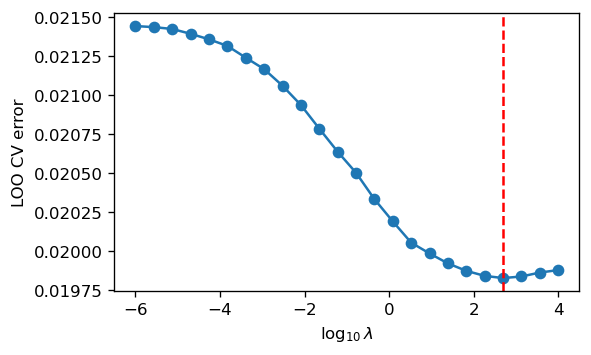

lamb_cv = 496.1947603002898


In [12]:
lamb_grid = np.geomspace(1e-6, 1e4, 24)[::-1]  # widened upper bound: cognate's sparse, largely-singleton
# character matrix pushed the true CV minimum to ~489 in a diagnostic check with a much
# wider grid (1e-6..1e6) -- phoneme/genetic's 1e-6..1e2 range was too narrow here and
# clipped lamb_cv at its boundary (100.0). 1e4 gives ~489 comfortable interior margin.

cv_err = run_cv(sp_graph, lamb_grid, n_folds=sp_graph.n_observed_nodes, factr=1e10)
mean_cv_err = np.mean(cv_err, axis=0)
lamb_cv = float(lamb_grid[np.argmin(mean_cv_err)])

fig, ax = plt.subplots(figsize=(5,3), dpi=120)
ax.plot(np.log10(lamb_grid), mean_cv_err, "o-")
ax.axvline(np.log10(lamb_cv), ls="--", c="r")
ax.set_xlabel(r"$\log_{10}\lambda$"); ax.set_ylabel("LOO CV error")
plt.show()

print("lamb_cv =", lamb_cv)
if np.argmin(mean_cv_err) in (0, len(lamb_grid)-1):
    print("WARNING: minimum at grid boundary -- widen lamb_grid")


In [13]:
sp_graph.fit(lamb=lamb_cv, optimize_q=None)

print("edges:", len(sp_graph.w))
print("log10(w/wbar):  min %.3f  max %.3f  sd %.3f" % (
    np.log10(sp_graph.w / sp_graph.w.mean()).min(),
    np.log10(sp_graph.w / sp_graph.w.mean()).max(),
    np.log10(sp_graph.w / sp_graph.w.mean()).std()))


edges: 232
log10(w/wbar):  min -0.256  max 0.167  sd 0.101


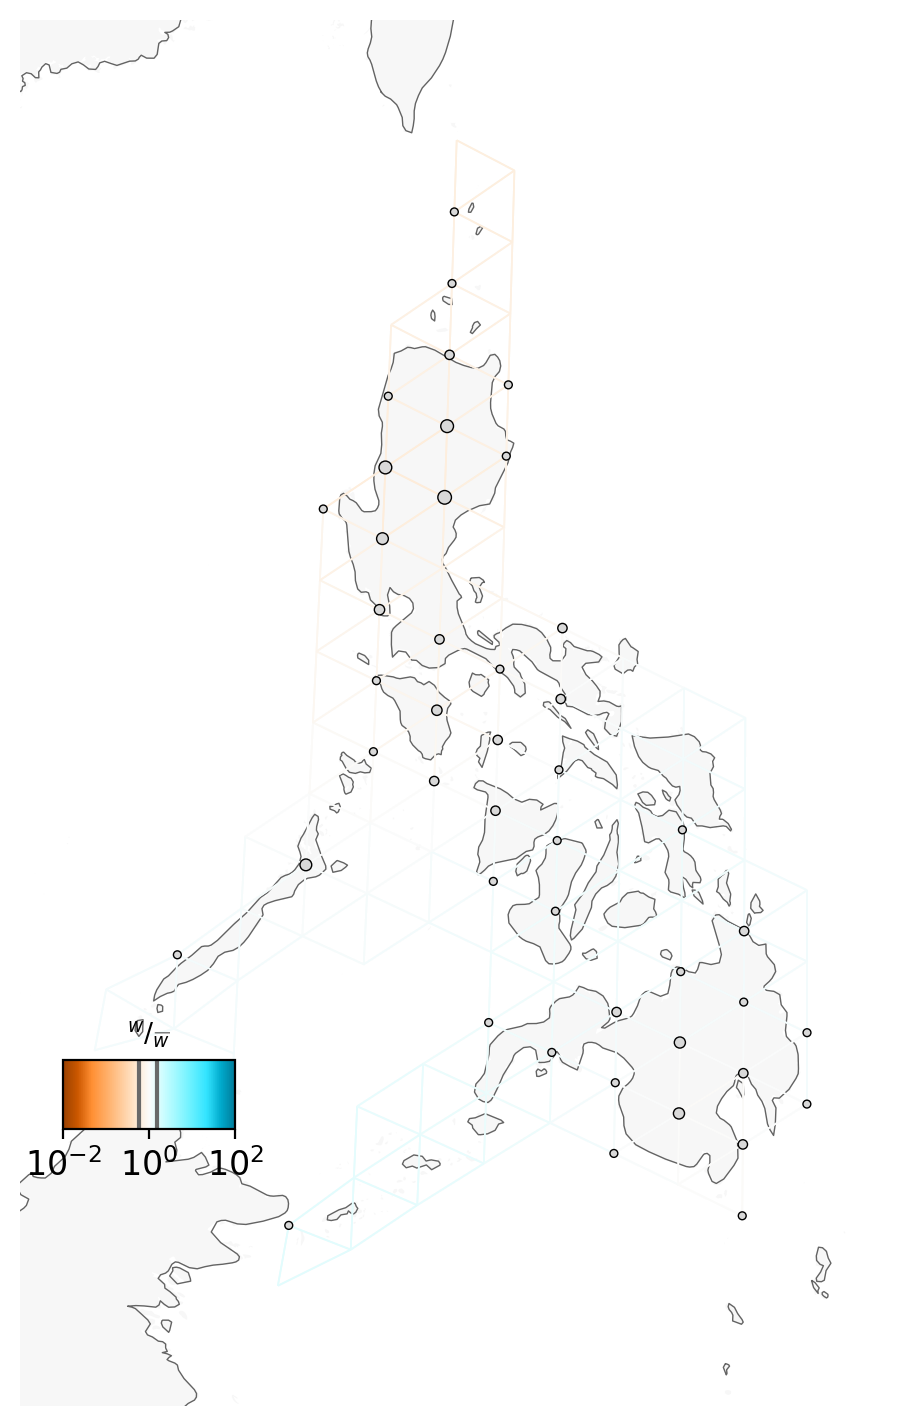

In [14]:
projection = ccrs.EquidistantConic(central_longitude=122.0, central_latitude=13.0)

fig = plt.figure(figsize=(7,9), dpi=200)
ax  = fig.add_subplot(1,1,1, projection=projection)
v = Viz(ax, sp_graph, projection=projection, edge_width=0.6,
        edge_alpha=1, edge_zorder=100, sample_pt_size=12,
        obs_node_size=8, sample_pt_color="black", cbar_font_size=8)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
v.draw_edge_colorbar()
plt.show()


In [15]:
n_nodes = sp_graph.node_pos.shape[0]
edge_arr = np.array(sp_graph.edges)          # (n_edges, 2), 0-indexed
log_w = np.log10(sp_graph.w / sp_graph.w.mean())

node_val = np.zeros(n_nodes)
node_cnt = np.zeros(n_nodes)
for k in range(len(edge_arr)):
    i, j = edge_arr[k]
    node_val[i] += log_w[k]; node_cnt[i] += 1
    node_val[j] += log_w[k]; node_cnt[j] += 1

node_val = np.divide(node_val, node_cnt, out=np.full(n_nodes, np.nan), where=node_cnt > 0)
print("isolated nodes (no edges, will be NaN):", np.isnan(node_val).sum())


isolated nodes (no edges, will be NaN): 0


In [16]:
triang = mtri.Triangulation(sp_graph.node_pos[:,0], sp_graph.node_pos[:,1])
interp = mtri.LinearTriInterpolator(triang, node_val)

RES = 300  # raster resolution; raise for a smoother/finer export
lon_g = np.linspace(outer[:,0].min(), outer[:,0].max(), RES)
lat_g = np.linspace(outer[:,1].min(), outer[:,1].max(), int(RES*4/3))
LON, LAT = np.meshgrid(lon_g, lat_g)
Z = interp(LON, LAT)

poly = Polygon(outer)   # reuse the exact outer polygon from the habitat cell
mask = np.array([[poly.contains(Point(LON[i,j], LAT[i,j])) for j in range(LON.shape[1])]
                  for i in range(LON.shape[0])])
Z = np.ma.array(Z, mask=~mask | np.ma.getmaskarray(Z))

print("valid raster fraction:", (~np.ma.getmaskarray(Z)).mean().round(3))


valid raster fraction: 0.457


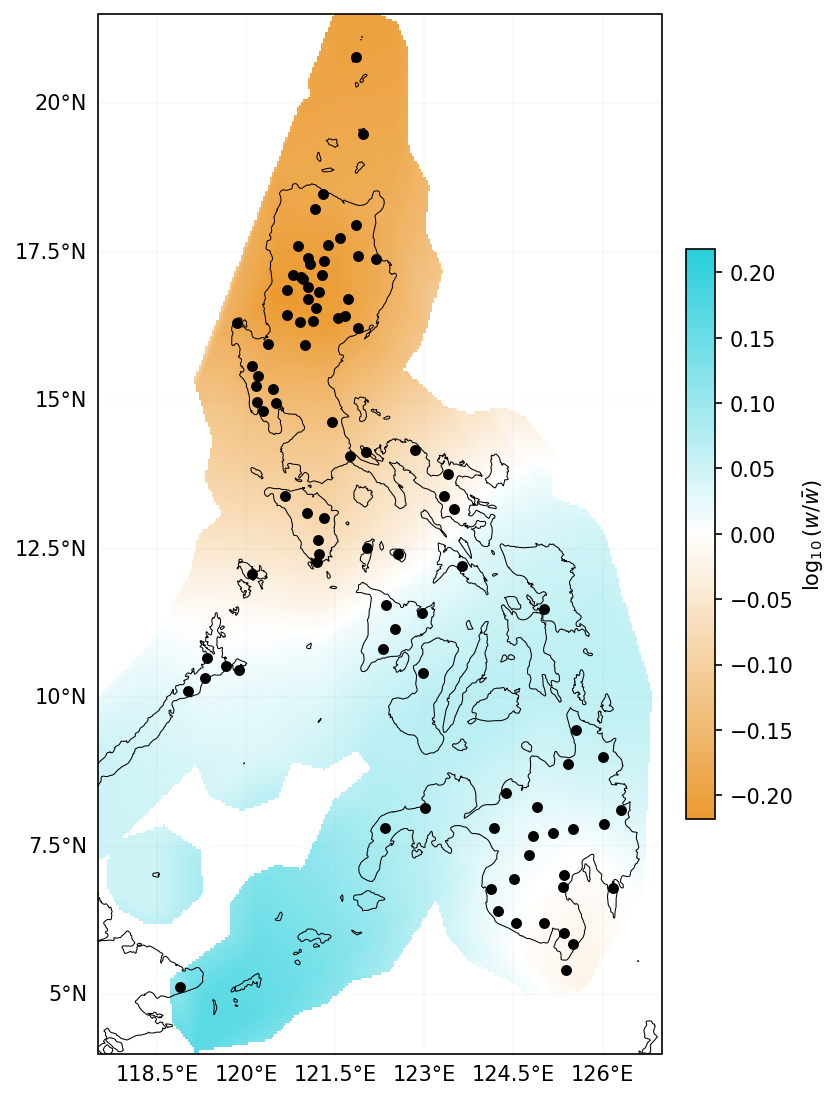

In [17]:
# EEMS-convention colormap: orange = low conductance (barrier), cyan = high
feems_cmap = LinearSegmentedColormap.from_list("feems_oc", ["#E8890C", "#FFFFFF", "#00C6D6"])

# symmetric about 0 so white always means "at the mean" -- do NOT let it auto-center
vmax = float(np.nanmax(np.abs(Z)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig = plt.figure(figsize=(7, 9), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([117.5, 127.0, 4.0, 21.5], crs=ccrs.PlateCarree())

pc = ax.pcolormesh(LON, LAT, Z, cmap=feems_cmap, norm=norm,
                   shading="auto", alpha=0.85, transform=ccrs.PlateCarree(), zorder=1)

ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.5, edgecolor="black", zorder=5)

ax.scatter(coord[:, 0], coord[:, 1], s=18, c="black",
           transform=ccrs.PlateCarree(), zorder=10)

cb = fig.colorbar(pc, ax=ax, fraction=0.035, pad=0.03)
cb.set_label(r"$\log_{10}(w/\bar{w})$")

gl = ax.gridlines(draw_labels=True, lw=0.2, alpha=0.3)
gl.top_labels = False; gl.right_labels = False
plt.show()


In [18]:
edge_arr = np.array(sp_graph.edges)          # 0-indexed, (n_edges, 2)

edgew_df = pd.DataFrame({
    "node_i": edge_arr[:, 0],
    "node_j": edge_arr[:, 1],
    "w": sp_graph.w,
    "log10_w_ratio": np.log10(sp_graph.w / sp_graph.w.mean()),
})
edgew_df.to_csv(UP/"edgew_cognate.csv", index=False)

nodepos_df = pd.DataFrame({
    "lon": sp_graph.node_pos[:, 0],
    "lat": sp_graph.node_pos[:, 1],
    "n_samples": [sp_graph.nodes[n]["n_samples"] for n in range(len(sp_graph.nodes))],
})
nodepos_df.to_csv(UP/"nodepos_cognate.csv", index=False)

print(edgew_df.shape, nodepos_df.shape)


(232, 4) (97, 3)


In [19]:
valid = ~np.ma.getmaskarray(Z)
raster_df = pd.DataFrame({
    "lon": LON[valid],
    "lat": LAT[valid],
    "log_w_ratio": Z[valid].data,
})
raster_df.to_csv(UP/"cognate_surface_raster.csv", index=False)
print(raster_df.shape)


(54804, 3)


In [20]:
meta = {
    "grid_res": GRID_RES,
    "habitat_source": "Natural Earth coastline (countries.geojson, name='Philippines')",
    "coast_buf": COAST_BUF,
    "n_nodes": int(grid.shape[0]),
    "n_edges": int(edges.shape[0]),
    "n_observed_nodes": int(sp_graph.n_observed_nodes),
    "scale_snps": bool(SCALE_SNPS),
    "use_idf": False,
    "optimize_q": None,
    "lamb_cv": float(lamb_cv),
    "n_features_retained": int(len(CHAR_KEEP)),
}
with open(UP / "cognate_feems_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(meta)


{'grid_res': 'grid_100.shp', 'habitat_source': "Natural Earth coastline (countries.geojson, name='Philippines')", 'coast_buf': 0.8, 'n_nodes': 97, 'n_edges': 232, 'n_observed_nodes': 45, 'scale_snps': True, 'use_idf': False, 'optimize_q': None, 'lamb_cv': 496.1947603002898, 'n_features_retained': 4648}


## Geographic-shuffle null permutation test

In [21]:
# Rasterize helper -- factors out the node-averaging + triangulation + masking that
# the cells above do inline, so the permutation loop below doesn't repeat it 100 times.
# The point-in-polygon mask itself is NOT recomputed here: node_pos/outer/grid never
# change across permutations (only which language sits at which node does), so the
# real run's `valid_mask` (built from Z's mask above) is reused as-is.
def rasterize_from_graph(sp_graph_x, LON, LAT, valid_mask):
    n_nodes = sp_graph_x.node_pos.shape[0]
    edge_arr = np.array(sp_graph_x.edges)
    log_w = np.log10(sp_graph_x.w / sp_graph_x.w.mean())

    node_val = np.zeros(n_nodes)
    node_cnt = np.zeros(n_nodes)
    for k in range(len(edge_arr)):
        i, j = edge_arr[k]
        node_val[i] += log_w[k]; node_cnt[i] += 1
        node_val[j] += log_w[k]; node_cnt[j] += 1
    node_val = np.divide(node_val, node_cnt, out=np.full(n_nodes, np.nan), where=node_cnt > 0)

    triang = mtri.Triangulation(sp_graph_x.node_pos[:, 0], sp_graph_x.node_pos[:, 1])
    interp = mtri.LinearTriInterpolator(triang, node_val)
    Zx = interp(LON, LAT)
    Zx = np.ma.array(Zx, mask=~valid_mask | np.ma.getmaskarray(Zx))
    return Zx


In [22]:
N_PERM = 100
BASE_SEED = 0
n = coord.shape[0]

# lamb_cv is reused unchanged from the real fit -- no CV inside the loop, which is
# what keeps 100 permutations to ~100 single .fit() calls instead of 100 full
# lambda sweeps.
valid_mask = ~np.ma.getmaskarray(Z)   # from the real run's raster above

raster_sum   = np.zeros_like(LON, dtype=float)
raster_count = np.zeros_like(LON, dtype=int)
pooled_null_vals = []
skipped = []

print(f"reusing lamb_cv = {lamb_cv} from the real fit -- no CV inside the permutation loop")


reusing lamb_cv = 496.1947603002898 from the real fit -- no CV inside the permutation loop


In [23]:
import io, time, contextlib

t0 = time.time()
for i in range(N_PERM):
    rng = np.random.default_rng(BASE_SEED + i)
    perm = rng.permutation(n)
    coord_null = coord[perm]              # shuffle geography only -- geno stays fixed/original order
    try:
        with contextlib.redirect_stdout(io.StringIO()):   # silence SpatialGraph's per-call chatter
            sp_graph_null = SpatialGraph(geno, coord_null, grid, edges, scale_snps=SCALE_SNPS)
            # occupancy is a property of the fixed point set, not the label assignment --
            # this should never fire; it's a cheap sanity check against an implementation bug.
            assert sp_graph_null.n_observed_nodes == sp_graph.n_observed_nodes
            sp_graph_null.fit(lamb=lamb_cv, optimize_q=None)
    except Exception as e:
        skipped.append((i, str(e)))
        continue

    Z_null = rasterize_from_graph(sp_graph_null, LON, LAT, valid_mask)
    ok = ~np.ma.getmaskarray(Z_null)
    raster_sum[ok]   += Z_null[ok].data
    raster_count[ok] += 1
    pooled_null_vals.append(Z_null[ok].data)

    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{N_PERM} permutations done ({time.time()-t0:.0f}s elapsed)")

print(f"completed {N_PERM - len(skipped)}/{N_PERM} permutations; skipped: {skipped}")


/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/spatial_graph.py:115: RuntimeWarning: divide by zero encountered in matmul
  self.S = self.frequencies @ self.frequencies.T / self.n_snps
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/spatial_graph.py:115: RuntimeWarning: overflow encountered in matmul
  self.S = self.frequencies @ self.frequencies.T / self.n_snps
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:39: RuntimeWarning: divide by zero encountered in matmul
  self.CDCt = self.C @ self.sp_graph.Dhat @ self.C.T
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:39: RuntimeWarning: overflow encountered in matmul
  self.CDCt = self.C @ self.sp_graph.Dhat @ self.C.T
/opt/miniconda3/envs/feems_env/lib/python3.10/site-packages/feems/objective.py:63: RuntimeWarning: divide by zero encountered in matmul
  X = U - np.outer(v, v @ B) / denom
/opt/miniconda3/envs/feems_env/lib/python3.10/site-pa

  20/100 permutations done (5s elapsed)


  40/100 permutations done (9s elapsed)


  60/100 permutations done (14s elapsed)


  80/100 permutations done (18s elapsed)


  100/100 permutations done (23s elapsed)
completed 100/100 permutations; skipped: []


In [24]:
null_mean = np.divide(raster_sum, raster_count, out=np.full_like(raster_sum, np.nan), where=raster_count > 0)
valid_mean = raster_count > 0

null_raster_df = pd.DataFrame({
    "lon": LON[valid_mean],
    "lat": LAT[valid_mean],
    "log_w_ratio_null_mean": null_mean[valid_mean],
})
null_raster_df.to_csv(UP / "cognate_surface_raster_null_mean.csv", index=False)
print(null_raster_df.shape)


(54804, 3)


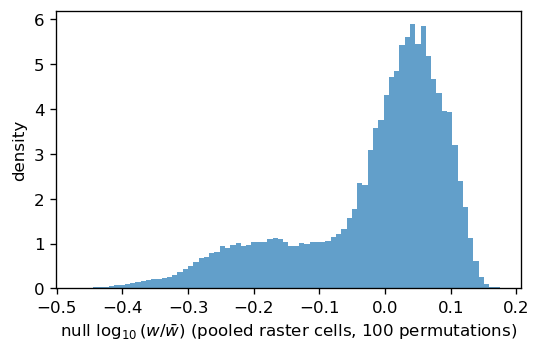

pooled null values: 5480400 | mean -0.0173 | sd 0.1149


In [25]:
# Density of pooled null raster values -- visual normality check.
pooled = np.concatenate(pooled_null_vals)

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.hist(pooled, bins=80, density=True, alpha=0.7)
ax.set_xlabel(r"null $\log_{10}(w/\bar{w})$ (pooled raster cells, 100 permutations)")
ax.set_ylabel("density")
plt.show()

print(f"pooled null values: {pooled.size} | mean {pooled.mean():.4f} | sd {pooled.std():.4f}")


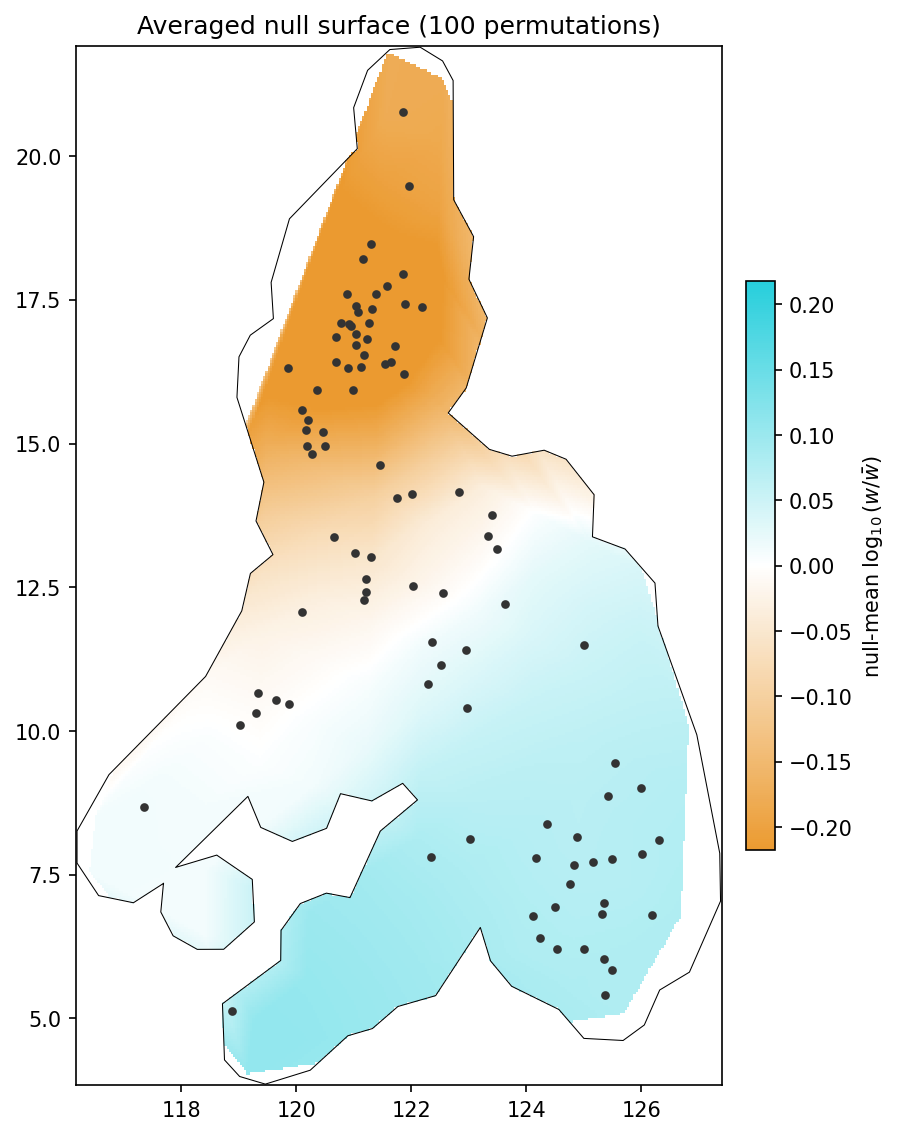

In [26]:
# Averaged null surface as a map -- same colormap/scale (feems_cmap, norm, vmax) as the
# real fit's map above, so the two are directly comparable: a flatter null surface
# should visibly wash out next to the real one under this shared scale.
fig, ax = plt.subplots(figsize=(7, 9), dpi=150)
pc = ax.pcolormesh(LON, LAT, np.ma.array(null_mean, mask=~valid_mean),
                    cmap=feems_cmap, norm=norm, shading="auto", alpha=0.85)
ax.plot(outer[:, 0], outer[:, 1], color="black", lw=0.5)
ax.scatter(coord[:, 0], coord[:, 1], s=10, c="0.2")
ax.set_aspect("equal")
cb = fig.colorbar(pc, ax=ax, fraction=0.035, pad=0.03)
cb.set_label(r"null-mean $\log_{10}(w/\bar{w})$")
ax.set_title(f"Averaged null surface ({N_PERM - len(skipped)} permutations)")
plt.show()
